In [32]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt

In [33]:
df = pd.read_csv("D:\\EduNet\\NSTI_Indore25_26\\Deep Learning\\Dataset\\temperature_data.csv")
df.head()

,Date,Temperature
0,2024-01-01,25.50
1,2024-01-02,25.54
2,2024-01-03,26.98
3,2024-01-04,28.47
4,2024-01-05,27.26


In [34]:
data = df['Temperature'].values

In [35]:
def sequencing(data, time_step=5):
    X,y = [],[]
    for i in range(len(data)-time_step):
        X.append(data[i:i+time_step])
        y.append(data[i+time_step])
    return np.array(X),np.array(y)

time_step = 5
X,y = sequencing(data,time_step)

In [36]:
X

array([[25.5 , 25.54, 26.98, 28.47, 27.26],
       [25.54, 26.98, 28.47, 27.26, 27.74],
       [26.98, 28.47, 27.26, 27.74, 29.93],
       [28.47, 27.26, 27.74, 29.93, 29.41],
       [27.26, 27.74, 29.93, 29.41, 28.35],
       [27.74, 29.93, 29.41, 28.35, 29.42],
       [29.93, 29.41, 28.35, 29.42, 28.37],
       [29.41, 28.35, 29.42, 28.37, 28.22],
       [28.35, 29.42, 28.37, 28.22, 28.69],
       [29.42, 28.37, 28.22, 28.69, 26.21],
       [28.37, 28.22, 28.69, 26.21, 26.01],
       [28.22, 28.69, 26.21, 26.01, 26.73],
       [28.69, 26.21, 26.01, 26.73, 25.81],
       [26.21, 26.01, 26.73, 25.81, 26.67],
       [26.01, 26.73, 25.81, 26.67, 24.98],
       [26.73, 25.81, 26.67, 24.98, 24.05],
       [25.81, 26.67, 24.98, 24.05, 26.56],
       [26.67, 24.98, 24.05, 26.56, 24.57],
       [24.98, 24.05, 26.56, 24.57, 24.65],
       [24.05, 26.56, 24.57, 24.65, 23.05],
       [26.56, 24.57, 24.65, 23.05, 23.92],
       [24.57, 24.65, 23.05, 23.92, 24.68],
       [24.65, 23.05, 23.92, 24.

In [37]:
y

array([27.74, 29.93, 29.41, 28.35, 29.42, 28.37, 28.22, 28.69, 26.21,
       26.01, 26.73, 25.81, 26.67, 24.98, 24.05, 26.56, 24.57, 24.65,
       23.05, 23.92, 24.68, 23.63, 25.47, 24.91, 25.72, 25.99, 29.07,
       27.87, 27.5 , 30.05, 28.65, 30.68, 29.04, 30.11, 31.99, 32.78,
       32.35, 32.09, 31.83, 30.47, 30.96, 30.87, 31.98, 30.82, 28.24])

In [38]:
X = X.reshape(X.shape[0], X.shape[1], 1)

print("X shape:", X.shape)  # (samples, time_steps, features)
print("y shape:", y.shape)

X shape: (45, 5, 1)
y shape: (45,)


In [44]:
X

array([[[25.5 ],
        [25.54],
        [26.98],
        [28.47],
        [27.26]],

       [[25.54],
        [26.98],
        [28.47],
        [27.26],
        [27.74]],

       [[26.98],
        [28.47],
        [27.26],
        [27.74],
        [29.93]],

       [[28.47],
        [27.26],
        [27.74],
        [29.93],
        [29.41]],

       [[27.26],
        [27.74],
        [29.93],
        [29.41],
        [28.35]],

       [[27.74],
        [29.93],
        [29.41],
        [28.35],
        [29.42]],

       [[29.93],
        [29.41],
        [28.35],
        [29.42],
        [28.37]],

       [[29.41],
        [28.35],
        [29.42],
        [28.37],
        [28.22]],

       [[28.35],
        [29.42],
        [28.37],
        [28.22],
        [28.69]],

       [[29.42],
        [28.37],
        [28.22],
        [28.69],
        [26.21]],

       [[28.37],
        [28.22],
        [28.69],
        [26.21],
        [26.01]],

       [[28.22],
        [28.69],
        [

In [39]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(50, activation='tanh', input_shape=(time_step, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

c:\Users\Jash\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [41]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=8,
    validation_data=(X_test, y_test)
)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 706.3627 - val_loss: 900.3823
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 682.3299 - val_loss: 878.3420
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 662.4564 - val_loss: 858.9789
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 643.9250 - val_loss: 839.3275
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 624.4587 - val_loss: 817.9428
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 603.1445 - val_loss: 793.5457
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 578.8099 - val_loss: 765.2676
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 552.2007 - val_loss: 732.8669
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 523.1104 - val_loss: 697.8488
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 493.3118 - val_loss: 661.7047
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 464.0432 - val_loss: 626.4101
Epoch 12/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1

In [42]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


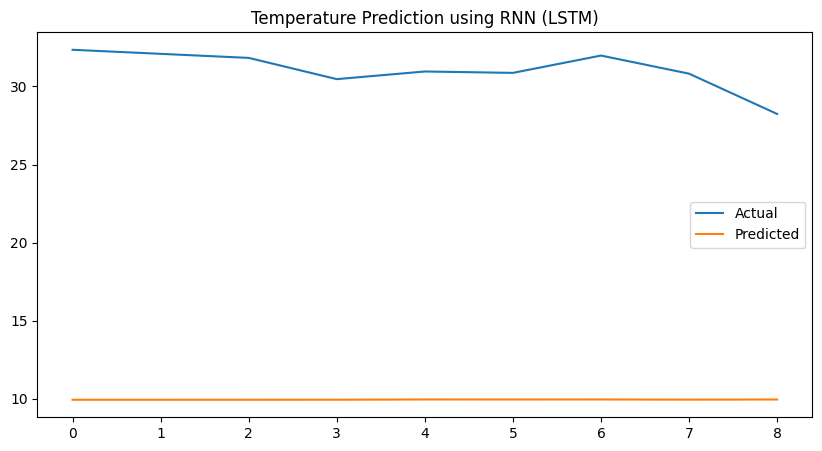

In [43]:
plt.figure(figsize=(10,5))

plt.plot(y_test, label="Actual")
plt.plot(test_pred, label="Predicted")

plt.legend()
plt.title("Temperature Prediction using RNN (LSTM)")
plt.show()